# Predicting war events

## I. Importing essential libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string

import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.notebook import tqdm
from tqdm import tqdm
import pymorphy3

import os
from pathlib import Path
import json

## II. Importing

In [2]:
weather = pd.read_csv("../data/all_weather_by_hour_2023-2025_v1.csv")

In [3]:
df_war_events_raw = pd.read_csv("../data/alarms-240222-010325.csv", sep=";")
df_regions = pd.read_csv("../data/regions.csv")

In [4]:
json_path_isw = Path("../data/isw_reports_v2.json")

with open(json_path_isw, "r", encoding="utf-8") as f:
    data = json.load(f)

df_isw_raw = pd.DataFrame(data)

print(type(df_isw_raw))

<class 'pandas.core.frame.DataFrame'>


In [5]:
json_path_tg = Path("../data/telegram_data.json")

with open(json_path_tg, "r", encoding="utf-8") as f:
    data = json.load(f)

df_tg_raw = pd.DataFrame(data)

print(type(df_tg_raw))

<class 'pandas.core.frame.DataFrame'>


## III. EDA

### Weather

In [6]:
weather.head()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,...,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
0,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1020.0,0.0,91.5,0.0,NaN,0.0,Overcast,snow,obs,remote
1,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.2,88.2,0.0,NaN,0.0,Partially cloudy,fog,obs,remote
2,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1022.0,10.0,100.0,NaN,NaN,NaN,Overcast,cloudy,obs,33177099999
3,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.1,92.0,0.0,NaN,0.0,Overcast,fog,obs,remote
4,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.0,93.8,0.0,NaN,0.0,Overcast,cloudy,obs,remote


In [7]:
weather.shape

(608304, 65)

In [8]:
weather['hour_datetime'].head(2000)

0       00:00:00
1       01:00:00
2       02:00:00
3       03:00:00
4       04:00:00
          ...   
1995    04:00:00
1996    05:00:00
1997    06:00:00
1998    07:00:00
1999    08:00:00
Name: hour_datetime, Length: 2000, dtype: object

In [9]:
weather.columns

Index(['city_latitude', 'city_longitude', 'city_resolvedAddress',
       'city_address', 'city_timezone', 'city_tzoffset', 'day_datetime',
       'day_datetimeEpoch', 'day_tempmax', 'day_tempmin', 'day_temp',
       'day_feelslikemax', 'day_feelslikemin', 'day_feelslike', 'day_dew',
       'day_humidity', 'day_precip', 'day_precipprob', 'day_precipcover',
       'day_snow', 'day_snowdepth', 'day_windgust', 'day_windspeed',
       'day_winddir', 'day_pressure', 'day_cloudcover', 'day_visibility',
       'day_solarradiation', 'day_solarenergy', 'day_uvindex', 'day_sunrise',
       'day_sunriseEpoch', 'day_sunset', 'day_sunsetEpoch', 'day_moonphase',
       'day_conditions', 'day_description', 'day_icon', 'day_source',
       'day_preciptype', 'day_stations', 'hour_datetime', 'hour_datetimeEpoch',
       'hour_temp', 'hour_feelslike', 'hour_humidity', 'hour_dew',
       'hour_precip', 'hour_precipprob', 'hour_snow', 'hour_snowdepth',
       'hour_preciptype', 'hour_windgust', 'hour_windsp

In [10]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608304 entries, 0 to 608303
Data columns (total 65 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   city_latitude         608304 non-null  float64
 1   city_longitude        608304 non-null  float64
 2   city_resolvedAddress  608304 non-null  object 
 3   city_address          608304 non-null  object 
 4   city_timezone         608304 non-null  object 
 5   city_tzoffset         608304 non-null  float64
 6   day_datetime          608304 non-null  object 
 7   day_datetimeEpoch     608304 non-null  int64  
 8   day_tempmax           608304 non-null  float64
 9   day_tempmin           608304 non-null  float64
 10  day_temp              608304 non-null  float64
 11  day_feelslikemax      608304 non-null  float64
 12  day_feelslikemin      608304 non-null  float64
 13  day_feelslike         608304 non-null  float64
 14  day_dew               608304 non-null  float64
 15  

In [11]:
weather.describe()

,city_latitude,city_longitude,city_tzoffset,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,...,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex
count,608304.000000,608304.000000,608304.0,6.083040e+05,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,...,608304.000000,608304.000000,608304.000000,608304.000000,608304.00000,331846.000000,608304.000000,603968.000000,521042.000000,603968.000000
mean,49.143238,30.142514,2.0,1.693217e+09,15.203232,6.253993,10.721077,14.287248,4.267318,9.254504,...,0.598141,23.769943,11.399938,189.830264,1016.91840,17.010448,64.811065,142.722294,0.595017,1.413903
std,1.337209,4.303973,0.0,2.748558e+07,10.592473,8.162055,9.207622,11.577354,9.929590,10.713666,...,2.615546,11.492758,6.517607,106.383976,8.68127,9.656796,37.318628,220.920973,0.828064,2.226545
min,46.472500,22.285100,2.0,1.645654e+09,-14.300000,-50.300000,-17.500000,-21.800000,-50.300000,-27.100000,...,0.000000,0.700000,0.000000,0.000000,973.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.292400,25.935500,2.0,1.669414e+09,5.900000,-0.200000,2.800000,3.800000,-3.800000,-0.100000,...,0.000000,14.800000,7.200000,98.000000,1011.20000,10.000000,30.000000,0.000000,0.000000,0.000000
50%,49.416800,30.737100,2.0,1.693256e+09,15.100000,6.100000,10.600000,15.100000,4.200000,9.900000,...,0.000000,22.300000,10.800000,191.900000,1016.60000,15.800000,80.000000,5.600000,0.100000,0.000000
75%,50.253600,34.551700,2.0,1.717016e+09,24.600000,13.200000,18.800000,24.600000,13.200000,18.800000,...,0.000000,31.000000,15.100000,287.200000,1022.00000,24.100000,99.900000,218.300000,1.000000,2.000000
max,51.493700,37.814500,2.0,1.740780e+09,60.400000,27.200000,33.200000,60.400000,28.000000,33.900000,...,107.000000,230.400000,90.000000,360.000000,1050.00000,75.000000,100.000000,952.000000,3.400000,10.000000


In [12]:
weather.isna().sum()

city_latitude              0
city_longitude             0
city_resolvedAddress       0
city_address               0
city_timezone              0
                        ... 
hour_uvindex            4336
hour_conditions            0
hour_icon                  0
hour_source                0
hour_stations              0
Length: 65, dtype: int64

In [13]:
weather.duplicated().sum()

np.int64(0)

In [14]:
weather = weather.drop(columns=[
    "city_resolvedAddress",
    "city_address",
    "day_stations",
    "day_source",
    "hour_source",
    "hour_icon",
    "hour_stations",
    "hour_datetimeEpoch",
    'hour_preciptype', 
    "hour_visibility",
    "day_visibility",
    'day_preciptype',
    "day_icon",
    "day_description",
    "day_datetimeEpoch",
    "day_sunriseEpoch",
    "day_sunsetEpoch"
])

In [15]:
weather.head()

,city_latitude,city_longitude,city_timezone,city_tzoffset,day_datetime,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,...,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions
0,50.7469,25.3263,Europe/Kiev,2.0,2022-02-24,4.9,0.7,2.6,4.0,-3.1,...,0.2,31.3,15.5,275.6,1020.0,91.5,0.0,NaN,0.0,Overcast
1,50.7469,25.3263,Europe/Kiev,2.0,2022-02-24,4.9,0.7,2.6,4.0,-3.1,...,0.2,27.7,14.8,280.3,1021.0,88.2,0.0,NaN,0.0,Partially cloudy
2,50.7469,25.3263,Europe/Kiev,2.0,2022-02-24,4.9,0.7,2.6,4.0,-3.1,...,0.1,29.2,14.4,310.0,1022.0,100.0,NaN,NaN,NaN,Overcast
3,50.7469,25.3263,Europe/Kiev,2.0,2022-02-24,4.9,0.7,2.6,4.0,-3.1,...,0.1,23.8,13.3,295.1,1021.0,92.0,0.0,NaN,0.0,Overcast
4,50.7469,25.3263,Europe/Kiev,2.0,2022-02-24,4.9,0.7,2.6,4.0,-3.1,...,0.1,24.5,13.3,305.8,1021.0,93.8,0.0,NaN,0.0,Overcast


In [16]:
weather['day_datetime'] = pd.to_datetime(weather['day_datetime'])
weather['hour_datetime'] = pd.to_datetime(weather['hour_datetime'])

weather['day'] = weather['day_datetime'].dt.day
weather['month'] = weather['day_datetime'].dt.month
weather['weekday'] = weather['day_datetime'].dt.weekday

weather['hour'] = weather['hour_datetime'].dt.hour

C:\Users\vikam\AppData\Local\Temp\ipykernel_8384\822816711.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather['hour_datetime'] = pd.to_datetime(weather['hour_datetime'])


In [17]:
weather['day_solarradiation'].fillna(weather['day_solarradiation'].median(), inplace=True)
weather['day_solarenergy'].fillna(weather['day_solarenergy'].median(), inplace=True)
weather['day_uvindex'].fillna(weather['day_uvindex'].median(), inplace=True)
weather['hour_solarradiation'].fillna(weather['hour_solarradiation'].median(), inplace=True)
weather['hour_solarenergy'].fillna(weather['hour_solarenergy'].median(), inplace=True)
weather['hour_uvindex'].fillna(weather['hour_uvindex'].median(), inplace=True)
weather['hour_precip'] = weather['hour_precip'].fillna(0)

C:\Users\vikam\AppData\Local\Temp\ipykernel_8384\3990248897.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  weather['day_solarradiation'].fillna(weather['day_solarradiation'].median(), inplace=True)
C:\Users\vikam\AppData\Local\Temp\ipykernel_8384\3990248897.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting v

In [18]:
weather = weather.drop(columns=['day_datetime','hour_datetime'])

In [19]:
weather.isna().sum()

city_latitude          0
city_longitude         0
city_timezone          0
city_tzoffset          0
day_tempmax            0
day_tempmin            0
day_temp               0
day_feelslikemax       0
day_feelslikemin       0
day_feelslike          0
day_dew                0
day_humidity           0
day_precip             0
day_precipprob         0
day_precipcover        0
day_snow               0
day_snowdepth          0
day_windgust           0
day_windspeed          0
day_winddir            0
day_pressure           0
day_cloudcover         0
day_solarradiation     0
day_solarenergy        0
day_uvindex            0
day_sunrise            0
day_sunset             0
day_moonphase          0
day_conditions         0
hour_temp              0
hour_feelslike         0
hour_humidity          0
hour_dew               0
hour_precip            0
hour_precipprob        0
hour_snow              0
hour_snowdepth         0
hour_windgust          0
hour_windspeed         0
hour_winddir           0


In [20]:
def simplify_weather(x):
    if 'Snow' in x:
        return 'Snow'
    if 'Rain' in x:
        return 'Rain'
    if 'Overcast' in x or 'cloudy' in x:
        return 'Cloudy'
    if 'Clear' in x:
        return 'Clear'
    if 'Fog' in x:
        return 'Fog'
    return 'Other'

weather['hour_conditions_simple'] = weather['hour_conditions'].apply(simplify_weather)
weather['day_conditions_simple'] = weather['day_conditions'].apply(simplify_weather)

In [21]:
weather = pd.get_dummies(weather, columns=['day_conditions_simple','hour_conditions_simple'])

In [22]:
weather.shape

(608304, 58)

In [23]:
weather.columns

Index(['city_latitude', 'city_longitude', 'city_timezone', 'city_tzoffset',
       'day_tempmax', 'day_tempmin', 'day_temp', 'day_feelslikemax',
       'day_feelslikemin', 'day_feelslike', 'day_dew', 'day_humidity',
       'day_precip', 'day_precipprob', 'day_precipcover', 'day_snow',
       'day_snowdepth', 'day_windgust', 'day_windspeed', 'day_winddir',
       'day_pressure', 'day_cloudcover', 'day_solarradiation',
       'day_solarenergy', 'day_uvindex', 'day_sunrise', 'day_sunset',
       'day_moonphase', 'day_conditions', 'hour_temp', 'hour_feelslike',
       'hour_humidity', 'hour_dew', 'hour_precip', 'hour_precipprob',
       'hour_snow', 'hour_snowdepth', 'hour_windgust', 'hour_windspeed',
       'hour_winddir', 'hour_pressure', 'hour_cloudcover',
       'hour_solarradiation', 'hour_solarenergy', 'hour_uvindex',
       'hour_conditions', 'day', 'month', 'weekday', 'hour',
       'day_conditions_simple_Clear', 'day_conditions_simple_Cloudy',
       'day_conditions_simple_Rain', 

In [24]:
weather[['day_conditions','hour_conditions']].nunique()

day_conditions     19
hour_conditions    16
dtype: int64

In [25]:
weather = weather.drop(columns=['day_tempmax','day_tempmin', 'hour_conditions', 'day_conditions'])

In [26]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608304 entries, 0 to 608303
Data columns (total 54 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   city_latitude                  608304 non-null  float64
 1   city_longitude                 608304 non-null  float64
 2   city_timezone                  608304 non-null  object 
 3   city_tzoffset                  608304 non-null  float64
 4   day_temp                       608304 non-null  float64
 5   day_feelslikemax               608304 non-null  float64
 6   day_feelslikemin               608304 non-null  float64
 7   day_feelslike                  608304 non-null  float64
 8   day_dew                        608304 non-null  float64
 9   day_humidity                   608304 non-null  float64
 10  day_precip                     608304 non-null  float64
 11  day_precipprob                 608304 non-null  float64
 12  day_precipcover               

In [27]:
corr = weather.corr(numeric_only=True)

In [28]:
weather.shape

(608304, 54)

In [29]:
weather.to_csv('weather_date.csv', index=False)

### War events (alarms)

In [30]:
df_war_events_raw.shape

(55788, 6)

In [31]:
df_war_events_raw.head()

,id,region_id,region_city,all_region,start,end
0,52432,12,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28
1,53292,23,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43
2,52080,3,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42
3,52857,19,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47
4,52700,18,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19


In [32]:
df_war_events_raw.sample(5)

,id,region_id,region_city,all_region,start,end
44271,145927,4,Дніпропетровська обл.,1,2024-08-01 22:58:44,2024-08-01 23:33:58
55082,157856,20,Херсонська обл.,1,2025-02-16 00:33:54,2025-02-16 01:53:03
22845,99695,5,Донецька обл.,1,2023-07-28 18:08:15,2023-07-28 19:52:58
46902,148894,19,Харківська обл.,1,2024-09-14 02:33:35,2024-09-14 03:00:17
15464,61076,8,Запорізька обл.,1,2023-01-28 14:52:57,2023-01-28 15:33:30


In [33]:
df_war_events_raw.describe()

,id,region_id,all_region
count,55788.000000,55788.000000,55788.000000
mean,109103.029935,12.178121,0.972180
std,38574.559928,6.474089,0.164457
min,1.000000,1.000000,0.000000
25%,68259.750000,6.000000,1.000000
50%,126918.500000,13.000000,1.000000
75%,143399.250000,19.000000,1.000000
max,158665.000000,25.000000,1.000000


In [34]:
df_war_events_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55788 entries, 0 to 55787
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           55788 non-null  int64 
 1   region_id    55788 non-null  int64 
 2   region_city  55788 non-null  object
 3   all_region   55788 non-null  int64 
 4   start        55788 non-null  object
 5   end          55788 non-null  object
dtypes: int64(3), object(3)
memory usage: 2.6+ MB


In [35]:
print("Missing values:\n", df_war_events_raw.isna().sum())
print("\nDuplicate rows:", df_war_events_raw.duplicated().sum())
print("Duplicate id:", df_war_events_raw.duplicated(subset=["id"]).sum())

Missing values:
 id             0
region_id      0
region_city    0
all_region     0
start          0
end            0
dtype: int64

Duplicate rows: 0
Duplicate id: 0


In [36]:
df_war_events_raw[df_war_events_raw["all_region"] == 0]["region_city"].value_counts()

region_city
Київ    1552
Name: count, dtype: int64

In [37]:
df_war_events = df_war_events_raw.copy()

In [38]:
df_war_events["start"] = pd.to_datetime(df_war_events["start"], errors="coerce")
df_war_events["end"] = pd.to_datetime(df_war_events["end"], errors="coerce")

print("Invalid start dates:", df_war_events["start"].isna().sum())
print("Invalid end dates:", df_war_events["end"].isna().sum())

print(df_war_events[["start", "end"]].dtypes)

Invalid start dates: 0
Invalid end dates: 0
start    datetime64[ns]
end      datetime64[ns]
dtype: object


In [39]:
print("Min start:", df_war_events["start"].min())
print("Max start:", df_war_events["start"].max())

print("Min end:", df_war_events["end"].min())
print("Max end:", df_war_events["end"].max())

Min start: 2022-02-24 07:43:17
Max start: 2025-03-01 23:26:07
Min end: 2022-02-24 09:52:28
Max end: 2025-03-02 02:44:07


In [40]:
df_war_events["duration_min"] = (df_war_events["end"] - df_war_events["start"]).dt.total_seconds() / 60

print(df_war_events["duration_min"].describe())

count    55788.000000
mean        72.798103
std         93.094316
min       -781.700000
25%         26.566667
50%         39.733333
75%         84.716667
max       3031.300000
Name: duration_min, dtype: float64


In [41]:
print("\nNegative durations:", (df_war_events["duration_min"] < 0).sum())
print("Zero durations:", (df_war_events["duration_min"] == 0).sum())


Negative durations: 1
Zero durations: 0


In [42]:
df_war_events[df_war_events["duration_min"] < 0]

,id,region_id,region_city,all_region,start,end,duration_min
47970,150000,17,Сумська обл.,1,2024-10-01 20:53:04,2024-10-01 07:51:22,-781.7


One anomalous record with a **negative duration** was found

In [43]:
df_war_events["region_key"] = (
    df_war_events["region_city"]
    .str.replace(" обл.", "")
    .replace({"Крим": "АР Крим"})
)

In [44]:
df_war_events.head()

,id,region_id,region_city,all_region,start,end,duration_min,region_key
0,52432,12,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,129.183333,Львівська
1,53292,23,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,191.000000,Чернігівська
2,52080,3,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,30.000000,Вінницька
3,52857,19,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47,48.000000,Харківська
4,52700,18,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19,420.716667,Тернопільська


In [45]:
alarm_regions = sorted(
    df_war_events[df_war_events["all_region"] == 1]["region_key"].unique()
)

regions = df_regions["region"]

missing_in_alarms = sorted(set(regions) - set(alarm_regions))
extra_in_alarms = sorted(set(alarm_regions) - set(regions))

print("Missing regions in alarms:", missing_in_alarms)
print("Extra regions in alarms:", extra_in_alarms)

Missing regions in alarms: ['Луганська']
Extra regions in alarms: []


**Luhansk region is missing** in the alarms dataset.

In [46]:
alarm_id_check = (
    df_war_events[df_war_events["all_region"] == 1][["region_id", "region_key"]]
    .drop_duplicates()
    .rename(columns={"region_id": "region_id_alarms"})
)

regions_id_check = (
    df_regions[["region_id", "region"]]
    .rename(columns={"region_id": "region_id_regions", "region": "region_key"})
)

id_check = alarm_id_check.merge(regions_id_check, on="region_key")

id_mismatch = id_check[id_check["region_id_alarms"] != id_check["region_id_regions"]]

print("Number of ID mismatches:", len(id_mismatch))
id_mismatch

Number of ID mismatches: 19


,region_id_alarms,region_key,region_id_regions
0,12,Львівська,13
1,23,Чернігівська,25
2,3,Вінницька,2
3,19,Харківська,20
4,18,Тернопільська,19
5,16,Рівненська,17
6,22,Черкаська,23
7,14,Одеська,15
9,2,Волинська,3
11,20,Херсонська,21


In [47]:
plt.rcParams.update({
    "axes.edgecolor": "#DDDDDD",
    "axes.labelcolor": "#222222",
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "xtick.labelsize": 9,
    "ytick.labelsize": 10,
    "grid.color": "#D9D9D9",
    "grid.alpha": 0.5,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE_DARK = "#1D4E89"
BLUE_MAIN = "#2F6DB3"
BLUE_SOFT = "#A9C6E8"
BLUE_LIGHT = "#DCEAF7"
RED_ACCENT = "#D1495B"
GOLD = "#F4A261"
TEXT_GREY = "#555555"

def style_ax(ax, grid_axis="y"):
    ax.grid(axis=grid_axis)
    ax.set_axisbelow(True)

def add_subtitle(fig, text):
    fig.text(0.125, 0.92, text, fontsize=10, color=TEXT_GREY)

In [48]:
df_plot = df_war_events.copy()

df_plot = df_plot[df_plot["duration_min"] > 0].copy() # keep only valid rows

df_plot["year_month"] = df_plot["start"].dt.to_period("M")
df_plot["hour"] = df_plot["start"].dt.hour
df_plot["weekday"] = df_plot["start"].dt.day_name()

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

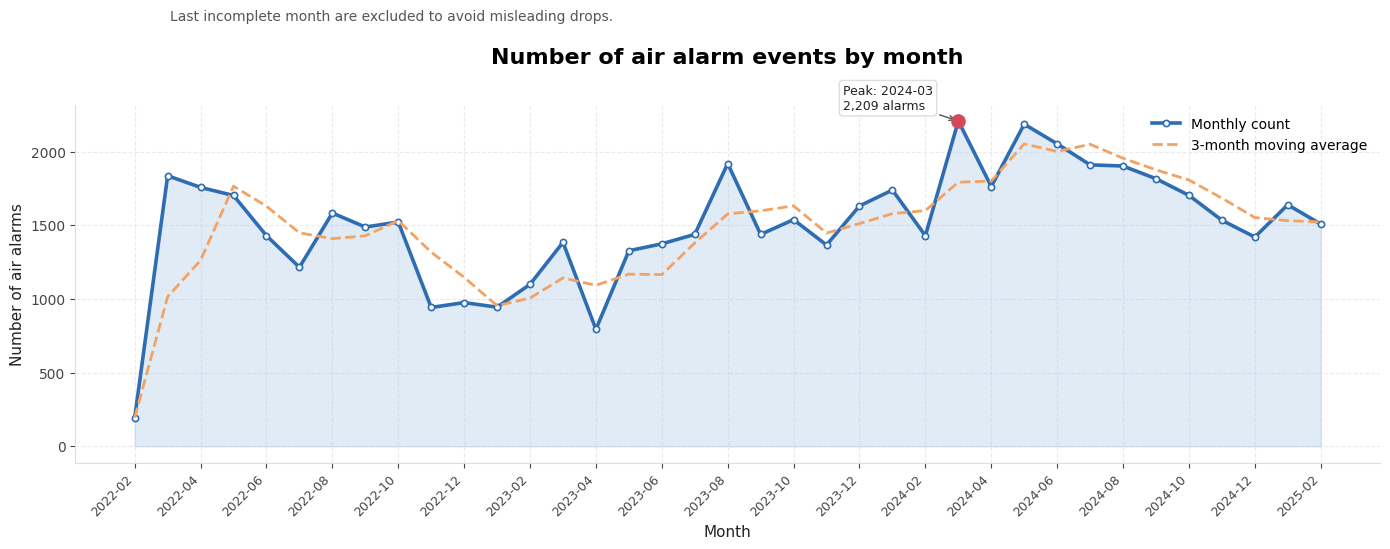

In [49]:
monthly_counts = df_plot.groupby("year_month").size().sort_index()
monthly_counts_plot = monthly_counts.iloc[:-1]

x_labels = monthly_counts_plot.index.astype(str).tolist()
y_values = monthly_counts_plot.values
x = np.arange(len(x_labels))
moving_avg = monthly_counts_plot.rolling(window=3, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.fill_between(x, y_values, color=BLUE_SOFT, alpha=0.35)
ax.plot(
    x, y_values,
    color=BLUE_MAIN, linewidth=2.6,
    marker="o", markersize=4.5,
    markerfacecolor="white",
    markeredgewidth=1.2,
    label="Monthly count"
)

ax.plot(
    x, moving_avg,
    color=GOLD, linewidth=2,
    linestyle="--",
    label="3-month moving average"
)

peak_idx = int(np.argmax(y_values))
ax.scatter(x[peak_idx], y_values[peak_idx], s=90, color=RED_ACCENT, zorder=5)

ax.annotate(
    f"Peak: {x_labels[peak_idx]}\n{y_values[peak_idx]:,} alarms",
    xy=(x[peak_idx], y_values[peak_idx]),
    xytext=(x[peak_idx] - 3.5, y_values[peak_idx] + 80),
    arrowprops=dict(arrowstyle="->", color=TEXT_GREY),
    fontsize=9,
    color="#222222",
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

tick_idx = np.arange(0, len(x_labels), 2)
ax.set_xticks(tick_idx)
ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45, ha="right")

ax.set_title("Number of air alarm events by month", pad=30)
ax.set_xlabel("Month")
ax.set_ylabel("Number of air alarms")

ax.legend(frameon=False)

style_ax(ax, "both")
add_subtitle(fig, "Last incomplete month are excluded to avoid misleading drops.")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

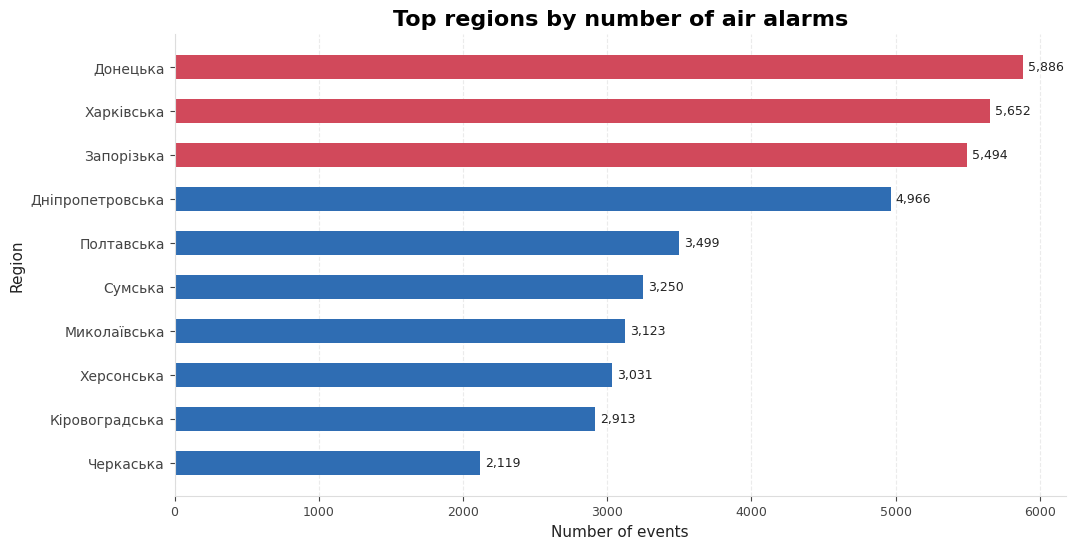

In [50]:
region_counts = df_plot.groupby("region_key").size().sort_values(ascending=False).head(10)

plot_region_counts = region_counts.sort_values()
top3_regions = set(region_counts.head(3).index)

bar_colors = [
    RED_ACCENT if region in top3_regions 
    else BLUE_MAIN for region in plot_region_counts.index
]

fig, ax = plt.subplots(figsize=(11.5, 6))

bars = ax.barh(
    plot_region_counts.index,
    plot_region_counts.values,
    color=bar_colors,
    height=0.55
)

for bar, value in zip(bars, plot_region_counts.values):
    ax.text(
        value + 35,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center",
        fontsize=9,
        color="#222222"
    )

ax.set_title("Top regions by number of air alarms")
ax.set_xlabel("Number of events")
ax.set_ylabel("Region")
style_ax(ax, "x")
plt.show()

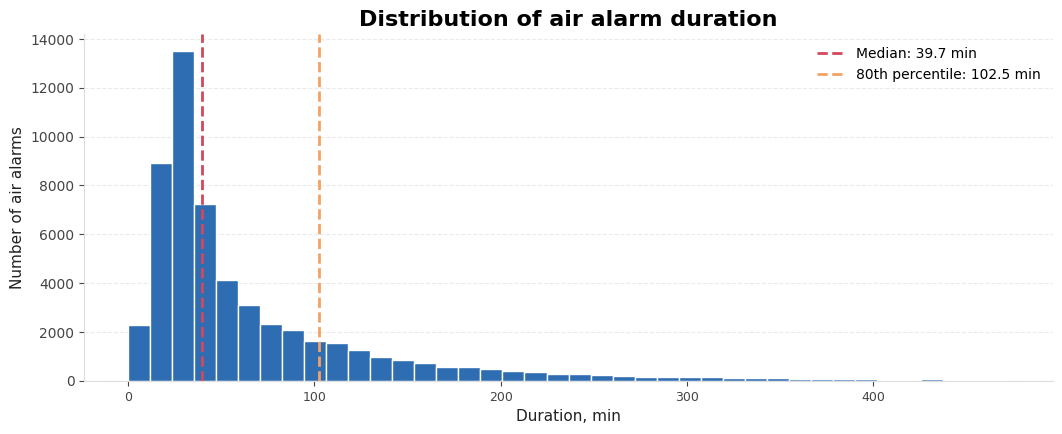

In [51]:
duration_min = df_plot["duration_min"].copy()
p99 = duration_min.quantile(0.99)
p80 = duration_min.quantile(0.80)
median_val = duration_min.median()

dur_clipped = duration_min[duration_min <= p99]

fig, ax = plt.subplots(figsize=(12.5, 4.5))

ax.hist(
    dur_clipped,
    bins=40,
    color=BLUE_MAIN,
    edgecolor="white"
)

ax.axvline(median_val, color=RED_ACCENT, linestyle="--", linewidth=2, label=f"Median: {median_val:.1f} min")
ax.axvline(p80, color=GOLD, linestyle="--", linewidth=2, label=f"80th percentile: {p80:.1f} min")

ax.set_title("Distribution of air alarm duration")
ax.set_xlabel("Duration, min")
ax.set_ylabel("Number of air alarms")
style_ax(ax, "y")
ax.legend(frameon=False, loc="upper right")
plt.show()

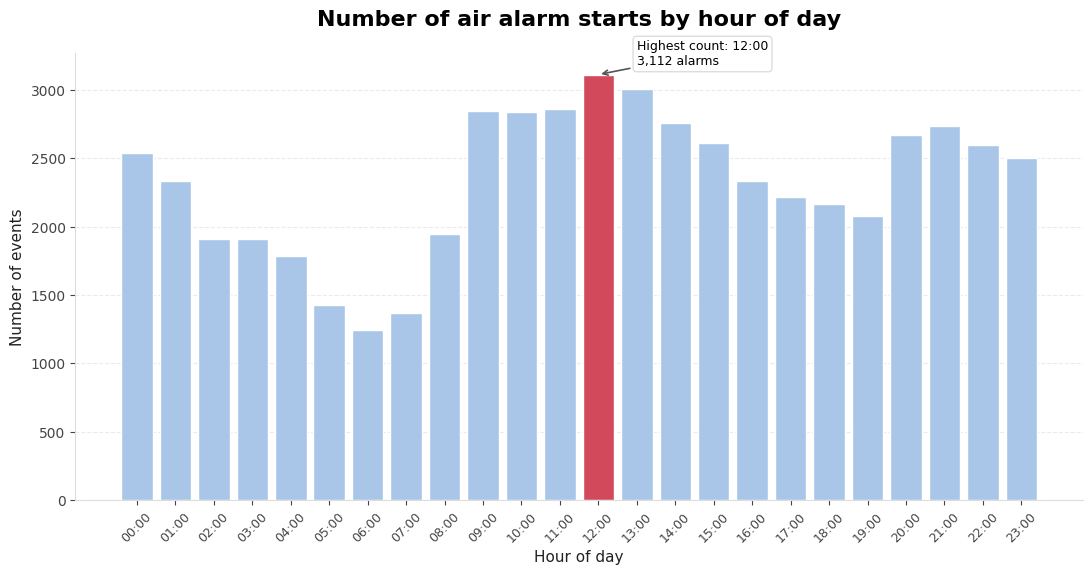

In [52]:
hour_counts = df_plot.groupby("hour").size()

top_hour = hour_counts.idxmax()
hour_colors = [BLUE_SOFT] * 24
hour_colors[top_hour] = RED_ACCENT

fig, ax = plt.subplots(figsize=(13, 5.8))
bars = ax.bar(
    hour_counts.index,
    hour_counts.values,
    color=hour_colors,
    edgecolor="white",
    width=0.82
)

ax.annotate(
    f"Highest count: {top_hour:02d}:00\n{hour_counts[top_hour]:,} alarms",
    xy=(top_hour, hour_counts[top_hour]),
    xytext=(top_hour + 1, hour_counts[top_hour] + 70),
    arrowprops=dict(arrowstyle="->", color=TEXT_GREY, lw=1.2),
    fontsize=9,
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)
ax.set_title("Number of air alarm starts by hour of day", pad=20)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of events")
style_ax(ax, "y")
plt.show()

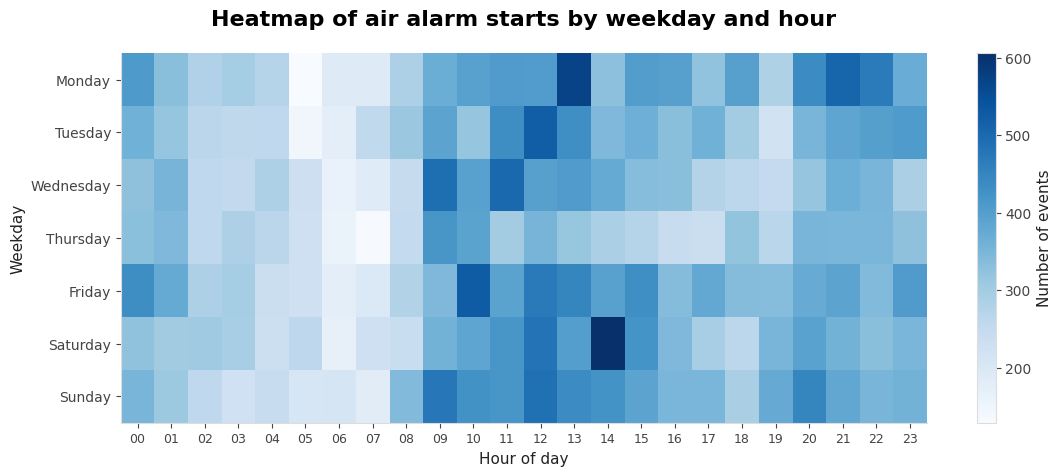

In [53]:
heatmap_data = (
    df_plot.groupby(["weekday", "hour"]).size()
    .reindex(pd.MultiIndex.from_product([weekday_order, range(24)]), fill_value=0)
    .unstack()
)

fig, ax = plt.subplots(figsize=(13, 4.8))
im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="Blues"
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)])
ax.set_yticks(range(len(weekday_order)))
ax.set_yticklabels(weekday_order)

ax.set_title("Heatmap of air alarm starts by weekday and hour", pad=20)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Weekday")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of events")
plt.show()

### ISW

In [54]:
df_isw_raw.shape

(1468, 4)

In [55]:
df_isw_raw.head()

,date,title,url,text
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
1,2022-02-24,Ukraine Conflict Update 7,https://understandingwar.org/research/russia-u...,Previous\nNext\nUkraine Conflict Update 7\nRus...
2,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
3,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
4,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...


In [56]:
df_isw_raw.sample(5)

,date,title,url,text
743,2024-03-07,"Russian Offensive Campaign Assessment, March 7...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
184,2022-08-26,"Russian Offensive Campaign Assessment, August ...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
961,2024-10-11,"Russian Offensive Campaign Assessment, October...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
217,2022-09-28,"Russian Offensive Campaign Assessment, Septemb...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
866,2024-07-08,"Russian Offensive Campaign Assessment, July 8,...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...


In [57]:
df_isw_raw.describe()

,date,title,url,text
count,1468,1468,1468,1468
unique,1467,1456,1456,1456
top,2022-02-24,None,None,None
freq,2,13,13,13


In [58]:
df_isw_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1468 non-null   object
 1   title   1468 non-null   object
 2   url     1468 non-null   object
 3   text    1468 non-null   object
dtypes: object(4)
memory usage: 46.0+ KB


All columns currently have the `object` data type. 

In [59]:
df_isw = df_isw_raw.copy()

In [60]:
for col in ["date","title", "url", "text"]:
    df_isw[col] = df_isw[col].replace("None", np.nan)

In [61]:
df_isw["date"] = pd.to_datetime(df_isw["date"], errors="coerce")
print("Invalid dates:", df_isw["date"].isna().sum())
print(df_isw["date"].dtype)

Invalid dates: 0
datetime64[ns]


In [62]:
print("Missing values:", df_isw.isna().sum())

Missing values: date      0
title    13
url      13
text     13
dtype: int64


In [63]:
print("Duplicate dates:", df_isw["date"].duplicated().sum())
print("Duplicate non-missing titles:", df_isw["title"].dropna().duplicated().sum())
print("Duplicate non-missing urls:", df_isw["url"].dropna().duplicated().sum())
print("Duplicate non-missing text:", df_isw["text"].dropna().duplicated().sum())
print("Duplicate full rows:", df_isw.duplicated().sum())
print("Duplicate non-missing titles:", df_isw["title"].duplicated().sum())

Duplicate dates: 1
Duplicate non-missing titles: 0
Duplicate non-missing urls: 0
Duplicate non-missing text: 0
Duplicate full rows: 0
Duplicate non-missing titles: 12


In [64]:
outside_range = df_isw[(df_isw["date"] < "2022-02-24") | (df_isw["date"] > "2026-03-01")]
print(outside_range)

Empty DataFrame
Columns: [date, title, url, text]
Index: []


In [65]:
def clean_isw_text(text):
    text = str(text)
    text = text.replace("Previous\nNext", "")
    text = text.replace("\n", " ")
    return text

df_isw["text_clean"] = df_isw["text"].apply(clean_isw_text)

In [66]:
df_isw.head()

,date,title,url,text,text_clean
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...,Russia-Ukraine Warning Update: Initial Russia...
1,2022-02-24,Ukraine Conflict Update 7,https://understandingwar.org/research/russia-u...,Previous\nNext\nUkraine Conflict Update 7\nRus...,Ukraine Conflict Update 7 Russia Team Februar...
2,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...,Russia-Ukraine Warning Update: Russian Offens...
3,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...,Russia-Ukraine Warning Update: Russian Offens...
4,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...,Russia-Ukraine Warning Update: Russian Offens...


In [67]:
df_isw["text"] = df_isw["text_clean"]
df_isw = df_isw.drop(columns=["text_clean"])

In [68]:
df_isw.head()

,date,title,url,text
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Initial Russia...
1,2022-02-24,Ukraine Conflict Update 7,https://understandingwar.org/research/russia-u...,Ukraine Conflict Update 7 Russia Team Februar...
2,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offens...
3,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offens...
4,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offens...


### Telegram 

In [69]:
df_tg_raw.shape

(129477, 3)

In [70]:
df_tg_raw.head()

,date,channel,message
0,2026-03-06 11:06:58+00:00,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...
1,2026-03-06 10:57:29+00:00,DeepStateUA,**🇺🇦**** Другий день обміну: додому **[**повер...
2,2026-03-06 06:32:47+00:00,DeepStateUA,🤬 **Угорщина затримала інкасаторські автомобіл...
3,2026-03-05 14:46:58+00:00,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...
4,2026-03-05 13:46:39+00:00,DeepStateUA,📋 **Зачистка з боку Сил Оборони на стику Запор...


In [71]:
df_tg_raw.sample(5)

,date,channel,message
52532,2023-02-13 13:01:39+00:00,UkraineNow,**Німеччина розпочала навчання військових ЗСУ ...
51107,2023-03-22 09:31:33+00:00,UkraineNow,"**""Укроборонпром"" відправив захисникам першу п..."
26566,2024-11-28 10:49:01+00:00,UkraineNow,**Рятувальники ліквідовують наслідки чергового...
40255,2024-01-11 14:25:42+00:00,UkraineNow,**Міноборони затвердило новий зразок бронежиле...
6572,2023-02-25 08:48:37+00:00,DeepStateUA,🇨🇳🇧🇾**Бульбофюрер планує відвідати Сі Цзіньпін...


In [72]:
df_tg_raw.describe()

,date,channel,message
count,129477,129477,129477
unique,129333,3,107432
top,2025-10-23 03:28:04+00:00,UkraineNow,📢 Відбій загрози.
freq,6,61363,929


In [73]:
df_tg_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129477 entries, 0 to 129476
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   date     129477 non-null  object
 1   channel  129477 non-null  object
 2   message  129477 non-null  object
dtypes: object(3)
memory usage: 3.0+ MB


In [74]:
print("Unique channels:", df_tg_raw["channel"].nunique())
print(df_tg_raw["channel"].value_counts())

Unique channels: 3
channel
UkraineNow     61363
kpszsu         56272
DeepStateUA    11842
Name: count, dtype: int64


In [ ]:
print("Duplicate rows:", df_tg_raw.duplicated().sum())

In [ ]:
df_tg = df_tg_raw.copy()

In [ ]:
df_tg["date"] = pd.to_datetime(df_tg["date"], utc=True, errors="coerce")
print("Invalid dates:", df_tg["date"].isna().sum())
print(df_isw["date"].dtype)

In [ ]:
print("Min date:", df_tg["date"].min())
print("Max date:", df_tg["date"].max())

In [ ]:
df_tg["message"] = df_tg["message"].astype(str)

print("Empty messages:", (df_tg["message"] == "").sum())
print("Whitespace messages:", df_tg["message"].str.strip().eq("").sum())

print("\nShortest messages:")
print(df_tg.loc[df_tg["message"].str.len().nsmallest(10).index, ["channel", "date", "message"]])

## IV. Prepare data

### Preparing ISW

In [ ]:
df_isw.head()

In [ ]:
df_isw['text'] = df_isw['text'].str.lower()

In [ ]:
df_isw['text'] = df_isw['text'].str.replace(f"[{string.punctuation}]", "", regex=True)

1. Підготовка

In [ ]:
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
isw_word_cache = {}

In [ ]:
def smart_preprocess_cached(text):
    text = str(text).lower()

    # Очистка
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s-]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)

    words = text.split()
    clean_words = []

    for w in words:
        # ПЕРЕВІРКА СТОП-СЛІВ
        if w in stop_words or len(w) <= 2:
            continue

        # КЕШУВАННЯ ЛЕМАТИЗАЦІЇ
        if w not in isw_word_cache:
            isw_word_cache[w] = lemmatizer.lemmatize(w)

        clean_words.append(isw_word_cache[w])

    return " ".join(clean_words)

2. Застосування

In [ ]:
tqdm.pandas()
print("Обробка текстів ISW...")
df_isw['text_final'] = df_isw['text'].progress_apply(smart_preprocess_cached)

3. Векторизація

In [ ]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=5)
X = vectorizer.fit_transform(df_isw['text_final'])

4. Результати

In [ ]:
print(f"Розмірність матриці: {X.shape}")
feature_names = vectorizer.get_feature_names_out()
print("Перші 20 ознак (тепер точно слова):")
print(feature_names[:20])

### Telegram

In [ ]:
tqdm.pandas()
morph = pymorphy3.MorphAnalyzer(lang='uk')
word_cache = {}

def fast_tg_clean_optimized(text):
    text = re.sub(r'https?://\S+|@\w+', '', str(text).lower())
    text = re.sub(r'[^а-яіїєґa-z\s-]', ' ', text)
    words = text.split()

    res = []
    for w in words:
        if len(w) < 3: continue

        if w not in word_cache:
            word_cache[w] = morph.parse(w)[0].normal_form
        res.append(word_cache[w])

    return " ".join(res)

print("Починаю очистку ТГ (це займе пару хвилин)...")
df_tg['message_clean'] = df_tg['message'].progress_apply(fast_tg_clean_optimized)

In [ ]:
vectorizer_tg = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    dtype=np.float32
)
X_tg = vectorizer_tg.fit_transform(df_tg['message_clean'])

print(X_tg.shape)